# Deep Reaserch

- Using
    - LangGraph
    - Ollama
    - Search tools (Google Serper, Tavily)

<br>

## Local Deep Research Agent Workflow

```txt
    ___start___
         |
        \./
    [generate_query]
         |
        \./
    [web_research]
         |
        \./
    [summarize_sources]
         |
        \./
    [reflect_on_summary] (OR) --> [web_research]
        (OR)
         |
        \./
    [finalize_summary]
         |
        \./
     ___end___
    
```


In [1]:
import os
import warnings
from pathlib import Path
from typing import Annotated, Any, Literal, TypedDict

# Standard imports
import numpy as np
import pandas as pd
import polars as pl

# Visualization
# import matplotlib.pyplot as plt

# NumPy settings
np.set_printoptions(precision=4)

# Pandas settings
pd.options.display.max_rows = 1_000
pd.options.display.max_columns = 1_000
pd.options.display.max_colwidth = 600

# Polars settings
pl.Config.set_fmt_str_lengths(1_000)
pl.Config.set_tbl_cols(n=1_000)
pl.Config.set_tbl_rows(n=200)

warnings.filterwarnings("ignore")

# Black code formatter (Optional)
%load_ext lab_black

# auto reload imports
%load_ext autoreload
%autoreload 2

In [2]:
from rich.console import Console
from rich.theme import Theme

custom_theme = Theme(
    {
        "white": "#FFFFFF",  # Bright white
        "info": "#00FF00",  # Bright green
        "warning": "#FFD700",  # Bright gold
        "error": "#FF1493",  # Deep pink
        "success": "#00FFFF",  # Cyan
        "highlight": "#FF4500",  # Orange-red
    }
)
console = Console(theme=custom_theme)


def create_path(path: str | Path) -> None:
    """
    Create parent directories for the given path if they don't exist.

    Parameters
    ----------
    path : str | Path
        The file path for which to create parent directories.
    """
    # Convert to Path object if it's a string
    path_obj: Path = Path(path) if isinstance(path, str) else path

    # Get the parent directory and create it if it doesn't exist
    path_obj.parent.mkdir(parents=True, exist_ok=True)


def go_up_from_current_directory(*, go_up: int = 1) -> None:
    """This is used to up a number of directories.

    Params:
    -------
    go_up: int, default=1
        This indicates the number of times to go back up from the current directory.

    Returns:
    --------
    None
    """
    import sys

    CONST: str = "../"
    NUM: str = CONST * go_up

    # Goto the previous directory
    prev_directory = os.path.join(os.path.dirname(__name__), NUM)
    # Get the 'absolute path' of the previous directory
    abs_path_prev_directory = os.path.abspath(prev_directory)

    # Add the path to the System paths
    sys.path.insert(0, abs_path_prev_directory)
    print(abs_path_prev_directory)

In [3]:
go_up_from_current_directory(go_up=2)

from model_config import LocalModel, RemoteModel  # noqa: E402
from settings import refresh_settings  # noqa: E402

settings = refresh_settings()

/Users/mac/Desktop


In [4]:
from langchain_openai import ChatOpenAI

model_str_remote: str = RemoteModel.QWEN3_30B_A3B
# model_str2_remote: str = RemoteModel.QWEN3_30B_A3B
model_str_local: str = LocalModel.LLAMA3_1_8B

remote_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
    base_url=settings.OPENROUTER_URL,
    temperature=0.0,
    model=model_str_remote,
)


local_llm = ChatOpenAI(
    api_key=settings.LMSTUDIO_API_KEY.get_secret_value(),
    base_url=settings.LMSTUDIO_URL,
    temperature=0.0,
    model=model_str_local,
)

### States

In [5]:
import operator
from dataclasses import dataclass, field


@dataclass(kw_only=True)
class SummaryState:
    research_topic: str = field(default="")
    search_query: str = field(default="")
    web_research_results: Annotated[list, operator.add] = field(default_factory=list)
    sources_gathered: Annotated[list, operator.add] = field(default_factory=list)
    research_loop_count: int = field(default=0)  # Research loop count
    existing_summary: str = field(default="")  # Final report


@dataclass(kw_only=True)
class SummaryStateInput:
    research_topic: str = field(default="")


@dataclass(kw_only=True)
class SummaryStateOutput:
    existing_summary: str = field(default="")

<br>

### Prompts

In [32]:
from datetime import datetime


# Get current date in a readable format
def get_current_date() -> str:
    """Get the current date in a readable format."""
    return datetime.now().strftime("%B %d, %Y")


query_writer_prompt: str = """
<GOAL>Your goal is to generate an optimized web search query based on the user's query</GOAL>

<CONTEXT>
Current date: {current_date}
Please ensure your queries account for the most current available information using the latest data available.
</CONTEXT>

<TOPIC> {research_topic} </TOPIC>

<EXAMPLE>
{{
    "query": "retrieval augmented generation (rag) explained simply",
    "rationale": "understanding the fundamental concept of retrieval augmented generation (rag)"
}}
</EXAMPLE>
"""

json_mode_query_prompt: str = """

<GOAL>
    Format your response as a JSON object with EXACTLY the following keys:
    - "query": The actual search query
    - "rationale": Brief explanation why this query is relevant
</GOAL>

<REQUIREMENTS>
    - Output MUST have the following keys:
      - "query"
      - "rationale"
</REQUIREMENTS>

<OUTPUT> Please provide your response in the specified JSON format: </OUTPUT>
"""

tool_calling_query_prompt: str = """

<GOAL>
    Use the `Query` tool with these required fields:
    - query: search terms
    - rationale: why this query helps
</GOAL>

<REQUIREMENTS>
    - Call the `Query` tool with the REQUIRED arguments
    - Output MUST have the following keys:
      - "query"
      - "rationale"
</REQUIREMENTS>

<OUTPUT>
    Please provide your response in the specified JSON format:
</OUTPUT>
"""

summarizer_prompt: str = """
<GOAL>
Generate a high-quality summary of maximum of 8 sentences of the provided context.
</GOAL>

<REQUIREMENTS>
    When creating a NEW summary:
    - Highlight the most relevant information related to the user topic from the search results
    - Ensure a coherent flow of information

    When EXTENDING an existing summary:         
    - Read the existing summary and new search results carefully.
    - Compare the new information with the existing summary.     
    - For each piece of new information:                         
        a. If it's related to existing points, integrate it into the relevant paragraph.                               
        b. If it's entirely new but relevant, add a new paragraph with a smooth transition.                            
        c. If it's not relevant to the user topic, skip it.        
    - Ensure all additions are relevant to the user's topic.     
    - Verify that your final output differs from the input summary.
</REQUIREMENTS>

<FORMATTING>
    - Start directly with the updated summary, without preamble or titles. Do not use XML tags in the output.
</FORMATTING>

<TASK>
    Think carefully about the provided Context first. Then generate a summary of the context to address the User Input.
</TASK>
"""

reflection_prompt: str = """
<ROLE>
    You are an expert research assistant analyzing a summary about {research_topic}.
    </ROLE>

    <GOAL>
    - Identify knowledge gaps or areas that need deeper exploration
    - Generate a follow-up question that would help expand your understanding
    - Focus on technical details, implementation specifics, or emerging trends that weren't fully covered
</GOAL>

<REQUIREMENTS>
    Ensure the follow-up question is self-contained and includes necessary context for web search.
</REQUIREMENTS>
"""

json_mode_reflection_prompt: str = """
<FORMAT>
    Format your response as a JSON object with **EXACTLY** the following keys:
    - knowledge_gap: Describe what information is missing or needs clarification
    - follow_up_query: Write a specific question to address this gap
</FORMAT>

<TASK>
    - Reflect carefully on the summary to identify knowledge gaps and produce a follow-up query. Then, produce 
    your output following this JSON format:
    {{
        "knowledge_gap": "The summary lacks information about performance metrics and benchmarks",
        "follow_up_query": "What are typical performance benchmarks and metrics used to evaluate [specific technology]?"
    }}
</TASK>

Provide your analysis in JSON format:
"""

tool_calling_reflection_prompt: str = """
<INSTRUCTIONS>
    Call the `FollowUpQuery` tool to format your response with **EXACTLY** the following keys:
    - follow_up_query: Write a specific question to address this gap
    - knowledge_gap: Describe what information is missing or needs clarification
</INSTRUCTIONS>

<TASK>
    Reflect carefully on the Summary to identify knowledge gaps and produce a follow-up query.
</TASK>

<REQUIREMENTS>
    - Call the `FollowUpQuery` tool with the REQUIRED arguments
    - Output must match have the following keys:
      - "follow_up_query"
      - "knowledge_gap"
</REQUIREMENTS>

<OUTPUT>
    Please provide your response in the specified JSON format:
</OUTPUT>
"""

### Configurations

In [33]:
from enum import Enum

from langchain_core.runnables import RunnableConfig
from pydantic import BaseModel, Field


class SearchAPI(str, Enum):
    SEARXNG: str = "searxng"
    EXA: str = "exa"
    TAVILY: str = "tavily"
    GOOGLE: str = "google"


class Configuration(BaseModel):
    """The configurable fields for the research assistant."""

    max_web_research_loops: int = Field(
        default=3,
        title="Research Depth",
        description="Number of research iterations to perform",
    )
    local_llm: str = Field(
        default=LocalModel.QWEN3_4B_INSTRUCT_2507,
        title="LLM Model Name",
        description="Name of the LLM model to use",
    )
    llm_provider: Literal["ollama", "lmstudio", "remote"] = Field(
        default="lmstudio",
        title="LLM Provider",
        description="Provider for the LLM (Ollama or LMStudio)",
    )
    search_api: Literal["tavily", "searxng", "google", "exa"] = Field(
        default="searxng", title="Search API", description="Web search API to use"
    )
    fetch_full_page: bool = Field(
        default=True,
        title="Fetch Full Page",
        description="Include the full page content in the search results",
    )
    ollama_base_url: str = Field(
        default="http://localhost:11434/",
        title="Ollama Base URL",
        description="Base URL for Ollama API",
    )
    lmstudio_base_url: str = Field(
        default="http://localhost:1234/v1",
        title="LMStudio Base URL",
        description="Base URL for LMStudio OpenAI-compatible API",
    )
    strip_thinking_tokens: bool = Field(
        default=True,
        title="Strip Thinking Tokens",
        description="Whether to strip <think> tokens from model responses",
    )
    use_tool_calling: bool = Field(
        default=False,
        title="Use Tool Calling",
        description="Use tool calling instead of JSON mode for structured output",
    )

    @classmethod
    def from_runnable_config(
        cls, config: RunnableConfig | None = None
    ) -> "Configuration":
        """
        Create a Configuration instance from a RunnableConfig.

        Parameters
        ----------
        config : RunnableConfig | None, optional
            A mapping-like object that may contain a "configurable" key whose value is a
            dictionary of configuration overrides. If None or the "configurable" key is
            absent, environment variables will be consulted for values.

        Returns
        -------
        Configuration
            A new Configuration instance populated with values sourced from environment
            variables `config["configurable"]`. Only keys that correspond to fields in
            `Configuration.model_fields` are considered; any entries with value ``None``
            are filtered out before instantiation.
        """
        configurable = (
            config["configurable"] if config and "configurable" in config else {}
        )

        # Get raw values from environment or config
        raw_values: dict[str, Any] = {
            name: os.environ.get(name.upper(), configurable.get(name))
            for name in cls.model_fields.keys()
        }

        # Filter out None values
        values = {k: v for k, v in raw_values.items() if v is not None}

        return cls(**values)

In [34]:
configuration: Configuration = Configuration.from_runnable_config()
configuration.model_dump()

{'max_web_research_loops': 2,
 'local_llm': <LocalModel.QWEN3_4B_INSTRUCT_2507: 'qwen3-4b-instruct-2507'>,
 'llm_provider': 'remote',
 'search_api': 'searxng',
 'fetch_full_page': True,
 'ollama_base_url': 'http://localhost:11434/',
 'lmstudio_base_url': 'http://localhost:1234/v1',
 'strip_thinking_tokens': True,
 'use_tool_calling': False}

### Utils

In [35]:
import json

import httpx
from langchain_community.utilities import GoogleSerperAPIWrapper, SearxSearchWrapper
from langchain_exa import ExaSearchResults
from langchain_tavily import TavilySearch
from markdownify import markdownify

# Constants
CHARS_PER_TOKEN: int = 4
MAX_TOKENS_PER_SOURCE: int = 1000


# utils.py


# utils.py
def strip_thinking_tokens(text: str) -> str:
    """
    Remove <think> and </think> tags and their content from the text.

    Iteratively removes all occurrences of content enclosed in thinking tokens.

    Args:
        text (str): The text to process

    Returns:
        str: The text with thinking tokens and their content removed
    """
    while "<think>" in text and "</think>" in text:
        start: int = text.find("<think>")
        end: int = text.find("</think>") + len("</think>")
        text = text[:start] + text[end:]
    return text


def get_llm(configurable: Configuration) -> ChatOpenAI:
    """Helper function to initialize LLM based on configuration.

    Uses JSON mode if use_tool_calling is False, otherwise regular mode for tool calling.

    Args:
        configurable: Configuration object containing LLM settings

    Returns:
        Configured LLM instance
    """
    if configurable.llm_provider == "lmstudio":
        return ChatOpenAI(
            api_key="empty",  # type: ignore
            base_url=settings.LMSTUDIO_URL,  # type: ignore
            model=LocalModel.MISTRAL_7B_INSTRUCT_V0_3_Q4_0,  # type: ignore
            temperature=0,
        )
    if configurable.llm_provider == "remote":
        return ChatOpenAI(
            api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
            base_url=settings.OPENROUTER_URL,  # type: ignore
            temperature=0.0,
            model=RemoteModel.GEMINI_2_0_FLASH_001,  # type: ignore
        )
    # Default to Ollama
    return ChatOpenAI(
        api_key="empty",  # type: ignore
        base_url=settings.OLLAMA_URL,  # type: ignore
        model=LocalModel.MISTRAL_7B_INSTRUCT_V0_3_Q4_0,  # type: ignore
        temperature=0,
    )


def format_sources(search_results: dict[str, Any]) -> str:
    """
    Format search results into a markdown-style bulleted list of sources.

    Parameters
    ----------
    search_results : dict[str, Any]
        Dictionary containing search results with a "results" key,
        where each result is a dictionary with "title" and "url".

    Returns
    -------
    str
        Markdown-formatted string listing each source as a bullet point.
    """
    return "\n".join(
        [f"* {src['title']}: {src['url']}" for src in search_results["results"]]
    )


def deduplicate_and_format_sources(
    search_response: dict[str, Any] | list[dict[str, Any]],
    max_tokens_per_source: int,
    fetch_full_page: bool = False,
) -> str:
    """
    Deduplicate search results by URL and format them into a plain-text source summary.

    Parameters
    ----------
    search_response : dict or list of dict
        Either a dictionary with a "results" key containing a list of result dicts, or a list
        of result dicts (or lists/dicts that contain "results"). Each result dict is expected
        to contain at minimum the keys "url", "title", and "content". Optionally results may
        include "raw_content".
    max_tokens_per_source : int
        Maximum number of tokens to include when including full source content. This is used
        to compute a character limit via CHARS_PER_TOKEN (characters ~= tokens * CHARS_PER_TOKEN).
    fetch_full_page : bool, optional
        If True, include truncated "raw_content" for each source according to the token limit.
        Default is False.

    Returns
    -------
    str
        A formatted plain-text string listing unique sources with their title, URL, the most
        relevant snippet, and optionally truncated full content.

    Raises
    ------
    ValueError
        If `search_response` is neither a dict with a "results" key nor a list of result dicts.

    Notes
    -----
    Deduplication is performed by URL (later items override earlier ones). The character limit
    for full content is computed as `max_tokens_per_source * CHARS_PER_TOKEN`. If a result has
    no "raw_content" and `fetch_full_page` is requested, an empty string will be used and a
    warning is printed.
    """
    # Convert input to list[result]
    if isinstance(search_response, dict):
        if "results" not in search_response:
            raise ValueError("Dict input must contain a 'results' key.")
        sources_list: list[Any] = search_response["results"]
    elif isinstance(search_response, list):
        sources_list = []
        for response in search_response:
            if isinstance(response, dict) and "results" in response:
                sources_list.extend(response["results"])
            else:
                sources_list.append(response)
    else:
        raise ValueError(
            "Input must either be a dict with `results` or a list of results."
        )

    # Deduplicate by URL (later entries override)
    unique_sources: dict[str, Any] = {
        src["url"]: src
        for src in sources_list
        if isinstance(src, dict) and "url" in src
    }

    # Format output
    formatted_text: str = "Sources:\n\n"
    for src in unique_sources.values():
        title: str = src.get("title", "<no title>")
        url: str = src.get("url", "<no url>")
        content: str = src.get("content", "")
        formatted_text += f"Source: {title}\n==\n"
        formatted_text += f"URL: {url}\n==\n"
        formatted_text += f"Most relevant content from source: : {content}\n==\n"
        if fetch_full_page:
            # Calculate rough estimates of characters per token
            char_limit: int = max_tokens_per_source * CHARS_PER_TOKEN
            raw_content: str = src.get("raw_content", "")
            if raw_content is None:
                raw_content = ""
                print(f"Warning: No raw_content found for source {url}")
            if len(raw_content) > char_limit:
                raw_content = raw_content[:char_limit] + "...</truncated>"
            formatted_text += f"Full source content limited to {max_tokens_per_source:,} tokens: {raw_content}\n\n"

    return formatted_text.strip()


def fetch_raw_content(url: str) -> str | None:
    """
    Fetch HTML content from a URL and convert it to markdown format.

    Parameters
    ----------
    url : str
        The URL to fetch content from.

    Returns
    -------
    str or None
        The fetched content converted to markdown if successful,
        None if any error occurs during fetching or conversion.

    Notes
    -----
    Uses a 10-second timeout to avoid hanging on slow sites or large pages.
    """
    try:
        # Create a client with reasonable timeout
        with httpx.Client(timeout=10.0) as client:
            response = client.get(url)
            response.raise_for_status()
            return markdownify(response.text)
    except Exception as e:
        print(f"Warning: Failed to fetch full page content for {url}: {str(e)}")
        return None


def searxng_search(
    query: str, max_results: int = 3, fetch_full_page: bool = False
) -> dict[str, list[dict[str, Any]]]:
    """
    Search the web using SearXNG with improved error handling.

    Parameters
    ----------
    query : str
        The search query string.
    max_results : int, optional
        Maximum number of results to return (default is 3).
    fetch_full_page : bool, optional
        If True, fetch and include the full page content for each result (default is False).

    Returns
    -------
    dict[str, list[dict[str, Any]]]
        Dictionary with a "results" key containing a list of result dictionaries.
        Each result dictionary contains:
            - "title": str, the result title
            - "url": str, the result URL
            - "content": str, the snippet or summary
            - "raw_content": str, the full page content if fetched, otherwise the snippet

    Notes
    -----
    Uses the SearxSearchWrapper for querying SearXNG. Handles incomplete results and fetch errors gracefully.
    """
    host = os.environ.get("SEARXNG_URL", "http://localhost:8080")

    try:
        s = SearxSearchWrapper(searx_host=host)
        results = []
        search_results = s.results(query, num_results=max_results)

        for r in search_results:
            url: str = r.get("link", "")
            title: str = r.get("title", "")
            content: str = r.get("snippet", "")

            if not all([url, title]):
                print(f"Warning: Incomplete result from SearXNG: {r}")
                continue

            raw_content = content
            if fetch_full_page:
                raw_content = fetch_raw_content(url)
                if raw_content is None:
                    raw_content = content

            result = {
                "title": title,
                "url": url,
                "content": content,
                "raw_content": raw_content,
            }
            results.append(result)

        return {"results": results}

    except Exception as e:
        print(f"SearXNG search failed: {str(e)}")
        return {"results": []}


def exa_search(
    query: str, max_results: int = 3, fetch_full_page: bool = False
) -> dict[str, list[dict[str, Any]]]:  # noqa: ARG001
    """
    Perform a web search using the ExaSearchResults tool.

    Parameters
    ----------
    query : str
        The search query string.
    max_results : int, optional
        Maximum number of results to return (default is 3).
    fetch_full_page : bool, optional
        If True, fetch and include the full page content for each result (default is False).

    Returns
    -------
    dict[str, list[dict[str, Any]]]
        Dictionary with a "results" key containing a list of result dictionaries.
        Each result dictionary contains:
            - "title": str, the result title
            - "url": str, the result URL
            - "content": str, truncated text content
            - "raw_content": str, the full text content

    Notes
    -----
    Uses the ExaSearchResults tool for querying Exa. Handles errors gracefully and truncates content to a character limit.
    """
    character_limit: int = 1_500
    # Initialize the ExaSearchResults tool
    search_tool = ExaSearchResults(exa_api_key=settings.EXA_API_KEY.get_secret_value())  # type: ignore

    try:
        # Perform a search query
        search_results = search_tool._run(  # noqa: SLF001
            query=query,
            num_results=max_results,
            text_contents_options=True,
            highlights=True,
        )
        results: list[dict[str, Any]] = [
            {
                "title": result.title,
                "url": result.url,
                "content": result.text[:character_limit] + "... </truncated>",
                "raw_content": result.text,
            }
            for result in search_results.results  # type: ignore
        ]
        return {"results": results}

    except Exception as e:
        print(f"Exa search failed: {str(e)}")
        return {"results": []}


def tavily_search(
    query: str, max_results: int = 3, fetch_full_page: bool = False
) -> dict[str, list[dict[str, Any]]]:  # noqa: ARG001
    """
    Perform a web search using the TavilySearch tool.

    Parameters
    ----------
    query : str
        The search query string.
    max_results : int, optional
        Maximum number of results to return (default is 3).
    fetch_full_page : bool, optional
        If True, fetch and include the full page content for each result (default is False).

    Returns
    -------
    dict[str, list[dict[str, Any]]]
        Dictionary with a "results" key containing a list of result dictionaries.
        Each result dictionary contains:
            - "title": str, the result title
            - "url": str, the result URL
            - "content": str, the snippet or summary
            - "raw_content": str, the full page content if fetched, otherwise the snippet

    Notes
    -----
    Uses the TavilySearch tool for querying Tavily. Handles errors gracefully.
    """
    search_tool = TavilySearch(max_results=max_results, topic="general")
    try:
        results: list[dict[str, Any]] = search_tool.invoke(query)["results"]
        return {"results": results}

    except Exception as e:
        print(f"Tavily search failed: {str(e)}")
    return {"results": []}


def google_search(
    query: str, max_results: int = 3, fetch_full_page: bool = False
) -> dict[str, list[dict[str, Any]]]:
    """
    Perform a web search using the GoogleSerperAPIWrapper.

    Parameters
    ----------
    query : str
        The search query string.
    max_results : int, optional
        Maximum number of results to return (default is 3).
    fetch_full_page : bool, optional
        If True, fetch and include the full page content for each result (default is False).

    Returns
    -------
    dict[str, list[dict[str, Any]]]
        Dictionary with a "results" key containing a list of result dictionaries.
        Each result dictionary contains:
            - "title": str, the result title
            - "url": str, the result URL
            - "content": str, the snippet or summary
            - "raw_content": str, the full page content if fetched, otherwise the snippet

    Notes
    -----
    Uses the GoogleSerperAPIWrapper for querying Google Serper. Handles errors gracefully.
    """
    search = GoogleSerperAPIWrapper(k=max_results)

    try:
        raw_results = search.results(query)

        results = [
            {
                "title": res["title"],
                "url": res["link"],
                "content": res["snippet"],
                "raw_content": res["snippet"],
            }
            for res in raw_results["organic"]
        ]
        if fetch_full_page:
            for res in results:
                res["raw_content"] = fetch_raw_content(res["url"])
        return {"results": results}

    except Exception as e:
        print(f"Google search failed: {str(e)}")
        return {"results": []}

### Nodes

In [36]:
from typing import Type, TypeVar

from langchain_core.messages import (
    AIMessage,
    AnyMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)
from langchain_core.runnables import RunnableConfig
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field

T = TypeVar("T", bound=BaseModel)


def generate_search_query_with_structured_output(
    configurable: Configuration,
    messages: list,
    tool_class: Type[T],
    fallback_query: str,
    tool_query_field: str,
    json_query_field: str,
) -> dict[str, Any]:
    """
    Generate a search query from LLM output using either tool-calling or JSON output.

    Parameters
    ----------
    configurable : Configuration
        Configuration object with LLM and mode settings.
    messages : list
        List of messages to send to the LLM.
    tool_class : Type[T]
        Tool class used for tool-calling mode (should be a pydantic BaseModel subclass).
    fallback_query : str
        Fallback search query to return if extraction fails.
    tool_query_field : str
        Field name in the tool call arguments that contains the query.
    json_query_field : str
        Field name in the JSON response that contains the query.

    Returns
    -------
    dict[str, Any]
        Dictionary containing the key "search_query" with the extracted or fallback query.

    Notes
    -----
    Local LLMs often perform better with JSON mode except when tool calling has an
    optimized prompt. The function attempts tool-calling extraction first when
    configurable.use_tool_calling is True, otherwise it parses JSON content.
    """
    if configurable.use_tool_calling:
        llm: ChatOpenAI = get_llm(configurable).bind_tools([tool_class])  # type: ignore
        result = llm.invoke(messages)

        if not result.tool_calls:  # type: ignore
            # If no tool calls were made
            return {"search_query": fallback_query}

        try:
            tool_data = result.tool_calls[0]["args"]  # type: ignore
            search_query = tool_data.get(tool_query_field)
            return {"search_query": search_query}

        except (IndexError, KeyError):
            return {"search_query": fallback_query}

    else:
        # Use JSON mode
        llm = get_llm(configurable)
        result = llm.invoke(messages)
        print(f"result: {result}")
        content: str = result.content  # type: ignore

        try:
            parsed_json: dict[str, Any] = json.loads(content)
            search_query = parsed_json.get(json_query_field)
            if not search_query:
                return {"search_query": fallback_query}
            return {"search_query": search_query}

        except (json.JSONDecodeError, KeyError):
            if configurable.strip_thinking_tokens:
                content = strip_thinking_tokens(content)
            return {"search_query": fallback_query}


def generate_query(state: SummaryState, config: RunnableConfig) -> dict[str, Any]:
    """
    Generate a search query for web search using LLM output.

    Parameters
    ----------
    state : SummaryState
        The current summary state containing the research topic.
    config : RunnableConfig
        Configuration for the LLM and query generation.

    Returns
    -------
    dict[str, Any]
        Dictionary containing the key "search_query" with the generated or fallback query.

    Notes
    -----
    The function formats a prompt using the current date and research topic, then uses either
    tool-calling or JSON mode to extract the search query from the LLM output.
    """

    # Format the prompt
    current_date: str = get_current_date()
    formatted_prompt = query_writer_prompt.format(
        current_date=current_date, research_topic=state.research_topic
    )

    # Generate a query
    configurable = Configuration.from_runnable_config(config)

    @tool
    class Query(BaseModel):
        """
        This tool is used to generate a query for web search.
        """

        query: str = Field(description="The actual search query string")
        rationale: str = Field(
            description="Brief explanation of why this query is relevant"
        )

    messages = [
        SystemMessage(
            content=formatted_prompt
            + (
                tool_calling_query_prompt
                if configurable.use_tool_calling
                else json_mode_query_prompt
            )
        ),
        HumanMessage(content="Generate a query for web search:"),
    ]

    return generate_search_query_with_structured_output(
        configurable=configurable,
        messages=messages,
        tool_class=Query,
        fallback_query=f"Tell me more about {state.research_topic}",
        tool_query_field="query",
        json_query_field="query",
    )


def web_research(state: SummaryState, config: RunnableConfig) -> dict[str, Any]:
    """
    LangGraph node that performs web research using the generated search query.

    Executes a web search using the configured search API (tavily, perplexity,
    duckduckgo, or searxng) and formats the results for further processing.

    Parameters
    ----------
    state : SummaryState
        The current summary state containing the search query and research loop count
    config : RunnableConfig
        Configuration for the runnable, including search API settings

    Returns
    -------
    dict[str, Any]
        Dictionary with state update, including sources_gathered, research_loop_count, and web_research_results
    """
    configurable = Configuration.from_runnable_config(config)
    search_api = configurable.search_api

    # Search the web
    if search_api == SearchAPI.SEARXNG:
        search_results: dict[str, list[dict[str, Any]]] = searxng_search(
            state.search_query,
            max_results=3,
            fetch_full_page=configurable.fetch_full_page,
        )
        search_str: str = deduplicate_and_format_sources(
            search_results,
            max_tokens_per_source=MAX_TOKENS_PER_SOURCE,
            fetch_full_page=configurable.fetch_full_page,
        )

    elif search_api == SearchAPI.EXA:
        search_results = exa_search(
            state.search_query,
            max_results=3,
            fetch_full_page=configurable.fetch_full_page,
        )
        search_str = deduplicate_and_format_sources(
            search_results,
            max_tokens_per_source=MAX_TOKENS_PER_SOURCE,
            fetch_full_page=configurable.fetch_full_page,
        )
    elif search_api == SearchAPI.TAVILY:
        search_results = tavily_search(
            state.search_query,
            max_results=3,
            fetch_full_page=configurable.fetch_full_page,
        )
        search_str = deduplicate_and_format_sources(
            search_results,
            max_tokens_per_source=MAX_TOKENS_PER_SOURCE,
            fetch_full_page=configurable.fetch_full_page,
        )
    elif search_api == SearchAPI.GOOGLE:
        search_results = google_search(
            state.search_query,
            max_results=3,
            fetch_full_page=configurable.fetch_full_page,
        )
        search_str = deduplicate_and_format_sources(
            search_results,
            max_tokens_per_source=MAX_TOKENS_PER_SOURCE,
            fetch_full_page=configurable.fetch_full_page,
        )
    else:
        raise ValueError(f"Unsupported search API: {configurable.search_api}")

    return {
        "sources_gathered": [format_sources(search_results)],
        "research_loop_count": state.research_loop_count + 1,
        "web_research_results": [search_str],
    }


def summarize_sources(state: SummaryState, config: RunnableConfig) -> Any:
    """
    LangGraph node that summarizes web research results.

    Uses an LLM to create or update a running summary based on the newest web research
    results, integrating them with any existing summary.

    Parameters
    ----------
    state : SummaryState
        The current summary state containing the research topic, running summary,
        and web research results
    config : RunnableConfig
        Configuration for the runnable, including LLM provider settings

    Returns
    -------
    dict[str, Any]
        Dictionary with state update, including running_summary key containing the updated summary
    """
    existing_summary = state.existing_summary
    most_recent_web_search = state.web_research_results[-1]

    # Human_message
    if existing_summary:
        human_msg_content: str = f"""
        <existing_summary>\n {existing_summary} \n </existing_summary>
        <new_context>\n {most_recent_web_search} \n </new_context>
        Update the existing_summary with the new context of this topic: <user_input> {state.research_topic} in <user_input>
        """
    else:
        human_msg_content = f"""
        <context>\n {most_recent_web_search} \n </context>
        Using this context: \n<user_input> {state.research_topic} in <user_input>
        create a summary
        """

    configurable = Configuration.from_runnable_config(config)
    llm: ChatOpenAI = get_llm(configurable)

    result = llm.invoke(
        [
            SystemMessage(content=summarizer_prompt),
            HumanMessage(content=human_msg_content),
        ]
    )
    existing_summary: str = result.content  # type: ignore
    if configurable.strip_thinking_tokens:
        existing_summary = strip_thinking_tokens(existing_summary)

    return {"existing_summary": existing_summary}


def reflect_on_summary(state: SummaryState, config: RunnableConfig) -> dict[str, Any]:
    """
    LangGraph node that identifies knowledge gaps and generates follow-up queries.

    Analyzes the current summary to identify areas for further research and generates
    a new search query to address those gaps. Uses structured output to extract
    the follow-up query in JSON format.

    Args:
        state: Current graph state containing the running summary and research topic
        config: Configuration for the runnable, including LLM provider settings

    Returns:
        Dictionary with state update, including search_query key containing the generated follow-up query
    """
    configurable = Configuration.from_runnable_config(config)
    formatted_prompt = reflection_prompt.format(research_topic=state.research_topic)

    @tool
    class FollowUpQuery(BaseModel):
        follow_up_query: str = Field(
            description="A specific question to address the knowledge gap"
        )
        knowledge_gap: str = Field(
            description="Describe what information is missing or needs clarification"
        )

    summary: str = "<SUMMARY>\n" + state.existing_summary + "\n</SUMMARY>"
    system_content = formatted_prompt + (
        tool_calling_reflection_prompt
        if configurable.use_tool_calling
        else json_mode_reflection_prompt + summary
    )

    messages: list[AnyMessage] = [SystemMessage(content=system_content)]
    return generate_search_query_with_structured_output(
        configurable=configurable,
        messages=messages,
        tool_class=FollowUpQuery,
        fallback_query=f"Tell me more about {state.research_topic}",
        tool_query_field="follow_up_query",
        json_query_field="follow_up_query",
    )


def finalize_summary(state: SummaryState) -> dict[str, Any]:
    """
    Parameters
    ----------
    state : SummaryState
        The current summary state containing the research topic, running summary,
        and web research results.

    Returns
    -------
    dict[str, Any]
        Dictionary with state update, including existing_summary key containing the updated summary
    """
    seen_sources: set = set()
    unique_sources: list[str] = []

    for src in state.sources_gathered:
        for line in src.split("\n"):
            # Process non-empty lines
            if line.strip() and line not in seen_sources:
                seen_sources.add(line)
                unique_sources.append(line)

    all_sources: str = "\n".join(unique_sources)
    state.existing_summary = (
        f"## Summary:\n{state.existing_summary}\n\n### Sources: \n{all_sources}"
    )

    return {"existing_summary": state.existing_summary}


def route_research(
    state: SummaryState, config: RunnableConfig
) -> Literal["finalize_summary", "web_research"]:
    """
    Route the research process based on the current research loop count.

    Parameters
    ----------
    state : SummaryState
        The current summary state containing the research loop count.
    config : RunnableConfig
        Configuration for the research process, including maximum allowed research loops.

    Returns
    -------
    Literal["finalize_summary", "web_research"]
        Returns "web_research" if the research loop count is less than or equal to the maximum allowed loops,
        otherwise returns "finalize_summary".
    """
    configurable = Configuration.from_runnable_config(config)
    if state.research_loop_count <= configurable.max_web_research_loops:
        return "web_research"
    return "finalize_summary"

### Graph

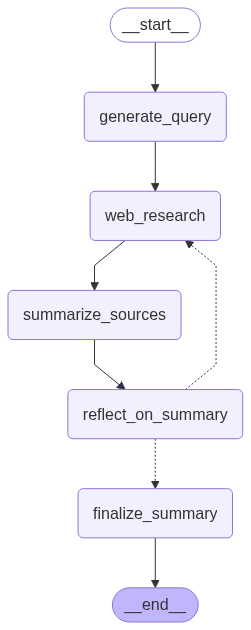

In [37]:
from IPython.display import Image, Markdown, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph

builder = StateGraph(
    state_schema=SummaryState,
    input_schema=SummaryStateInput,
    output_schema=SummaryStateOutput,
    config_schema=Configuration,
)

# Nodes
builder.add_node(generate_query, "generate_query")
builder.add_node(web_research, "web_research")
builder.add_node(summarize_sources, "summarize_sources")
builder.add_node(reflect_on_summary, "reflect_on_summary")
builder.add_node(finalize_summary, "finalize_summary")

# Edges
builder.add_edge(START, "generate_query")
builder.add_edge("generate_query", "web_research")
builder.add_edge("web_research", "summarize_sources")
builder.add_edge("summarize_sources", "reflect_on_summary")
builder.add_conditional_edges("reflect_on_summary", route_research)
builder.add_edge("finalize_summary", END)

# Build
memory = MemorySaver()
research_graph = builder.compile(checkpointer=memory)

# Visualize the graph
display(Image(research_graph.get_graph(xray=1).draw_mermaid_png()))

In [38]:
config = {"configurable": {"thread_id": "1"}}

topic: str = "Cole Palmer"  # "Fantasy Premier League"
responses = await research_graph.ainvoke(
    {"research_topic": topic},
    config=config,
)

console.print(responses)

result: content='```json\n{\n    "query": "Cole Palmer transfer news 2025",\n    "rationale": "To find the latest information on Cole Palmer\'s potential or actual transfers in the current year."\n}\n```' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 222, 'total_tokens': 272, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_name': 'google/gemini-2.0-flash-001', 'system_fingerprint': None, 'id': 'gen-1758054554-MSkPiikhv80gWIo4D526', 'service_tier': None, 'finish_reason': 'stop', 'logprobs': None} id='run--78e9fb8e-462b-4bc8-a5d6-0a09e3bc25a4-0' usage_metadata={'input_tokens': 222, 'output_tokens': 50, 'total_tokens': 272, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 0}}
result: content='```json

{
    'existing_summary': "## Summary:\nCole Palmer, born on May 6, 2002, in Wythenshawe, Manchester, is an English 
attacking football player. Known for his ability to both create and score goals, Palmer's first year at Stamford 
Bridge has been highly successful after joining Chelsea from Manchester City in September 2023. He has represented 
England in international competitions, including UEFA Euro 2024, where he scored the equalizing goal in the final. 
A profile on Chelsea's official site highlights his outstanding all-around quality. An article containing 40 facts 
about Cole Palmer, detailing his career and achievements, was published in July 2024.\n\n\n### Sources: \n* Cole 
Palmer - Wikipedia: https://en.wikipedia.org/wiki/Cole_Palmer\n* Cole Palmer joined from Manchester City on 
transfer deadline day in September 2023.: https://www.chelseafc.com/en/teams/profile/cole-palmer\n* 40 Facts About 
Cole Palmer: https://facts.net/lifestyle/sports/40-facts-about-cole-palmer/"
}

In [39]:
responses.keys()

dict_keys(['existing_summary'])

In [40]:
try:
    display(Markdown(responses[-1][-1].get("existing_summary", "")))
except Exception:
    display(Markdown(responses.get("existing_summary", "")))

## Summary:
Cole Palmer, born on May 6, 2002, in Wythenshawe, Manchester, is an English attacking football player. Known for his ability to both create and score goals, Palmer's first year at Stamford Bridge has been highly successful after joining Chelsea from Manchester City in September 2023. He has represented England in international competitions, including UEFA Euro 2024, where he scored the equalizing goal in the final. A profile on Chelsea's official site highlights his outstanding all-around quality. An article containing 40 facts about Cole Palmer, detailing his career and achievements, was published in July 2024.


### Sources: 
* Cole Palmer - Wikipedia: https://en.wikipedia.org/wiki/Cole_Palmer
* Cole Palmer joined from Manchester City on transfer deadline day in September 2023.: https://www.chelseafc.com/en/teams/profile/cole-palmer
* 40 Facts About Cole Palmer: https://facts.net/lifestyle/sports/40-facts-about-cole-palmer/

In [ ]:
res = {
    "user_id": "81525ef5-9e34-4a48-95a7-2c4c43e08b27",
    "response": {
        "existing_summary": "## Summary:\nJamie Gittens, the English winger born in 2004, joined Chelsea on a long-term contract through 2032 after leaving Borussia Dortmund, with transfer details including the fee and his shirt number reportedly confirmed. Chelsea’s signing is aimed at strengthening their attacking options with a player who brings substantial European experience under Enzo Maresca. Gittens progressed through Reading, Chelsea and Manchester City before moving to Dortmund in 2020, made his professional debut in 2022, and has since exceeded 100 appearances, scoring eight Bundesliga goals and four Champions League goals in 2024/25, including a Champions League goal against Milan in 2023 and a substitute appearance in the 2024 final vs Real Madrid. He operates mainly on the left but can also play as a No. 10 or in midfield, and he cannot represent Chelsea in the Club World Cup due to Dortmund group-stage appearances, with Chelsea integrating him ahead of future competitions.\n\n### Sources: \n* Jamie Gittens - Wikipedia: https://en.wikipedia.org/wiki/Jamie_Gittens\n* Jamie Gittens joined from Borussia Dortmund on 5 July 2025, with the winger signing a contract until 2032.: https://www.chelseafc.com/en/teams/profile/jamie-gittens\n* Everything you need to know about Jamie Gittens | News | Official Site | Chelsea Football Club: https://www.chelseafc.com/en/news/article/everything-you-need-to-know-about-jamie-gittens\n* I 'was' or I 'were'? - English Language Learners Stack Exchange: https://ell.stackexchange.com/questions/89843/i-was-or-i-were\n* Inside Jamie Gittens’ transfer to Chelsea: Talks last summer, Bayern interest, friends reunited - The Athletic: https://www.nytimes.com/athletic/6479998/2025/07/10/jamie-gittens-chelsea-dortmund-transfer/\n* Summer transfer window: Grading big signings in men's ...: https://www.espn.com/soccer/story/_/id/45342881/summer-transfer-window-grading-big-signings-mens-soccer\n* Inloggen bij Exact. Altijd toegang tot je cijfers. | Exact: https://www.exact.com/nl/login\n* Jamie Gittens to Chelsea: Transfer fee, contract length & shirt number: https://www.si.com/onsi/soccer/chelsea/news/jamie-gittens-to-chelsea-transfer-fee-contract-length-shirt-number-confirmed-01jzdh3233gf\n* Cole Palmer has one major weakness: https://www.facebook.com/groups/334067803877168/posts/1793474347936499/"
    },
}
display(Markdown(res.get("response", {}).get("existing_summary", "")))

## Summary:
Jamie Gittens, the English winger born in 2004, joined Chelsea on a long-term contract through 2032 after leaving Borussia Dortmund, with transfer details including the fee and his shirt number reportedly confirmed. Chelsea’s signing is aimed at strengthening their attacking options with a player who brings substantial European experience under Enzo Maresca. Gittens progressed through Reading, Chelsea and Manchester City before moving to Dortmund in 2020, made his professional debut in 2022, and has since exceeded 100 appearances, scoring eight Bundesliga goals and four Champions League goals in 2024/25, including a Champions League goal against Milan in 2023 and a substitute appearance in the 2024 final vs Real Madrid. He operates mainly on the left but can also play as a No. 10 or in midfield, and he cannot represent Chelsea in the Club World Cup due to Dortmund group-stage appearances, with Chelsea integrating him ahead of future competitions.

### Sources: 
* Jamie Gittens - Wikipedia: https://en.wikipedia.org/wiki/Jamie_Gittens
* Jamie Gittens joined from Borussia Dortmund on 5 July 2025, with the winger signing a contract until 2032.: https://www.chelseafc.com/en/teams/profile/jamie-gittens
* Everything you need to know about Jamie Gittens | News | Official Site | Chelsea Football Club: https://www.chelseafc.com/en/news/article/everything-you-need-to-know-about-jamie-gittens
* I 'was' or I 'were'? - English Language Learners Stack Exchange: https://ell.stackexchange.com/questions/89843/i-was-or-i-were
* Inside Jamie Gittens’ transfer to Chelsea: Talks last summer, Bayern interest, friends reunited - The Athletic: https://www.nytimes.com/athletic/6479998/2025/07/10/jamie-gittens-chelsea-dortmund-transfer/
* Summer transfer window: Grading big signings in men's ...: https://www.espn.com/soccer/story/_/id/45342881/summer-transfer-window-grading-big-signings-mens-soccer
* Inloggen bij Exact. Altijd toegang tot je cijfers. | Exact: https://www.exact.com/nl/login
* Jamie Gittens to Chelsea: Transfer fee, contract length & shirt number: https://www.si.com/onsi/soccer/chelsea/news/jamie-gittens-to-chelsea-transfer-fee-contract-length-shirt-number-confirmed-01jzdh3233gf
* Cole Palmer has one major weakness: https://www.facebook.com/groups/334067803877168/posts/1793474347936499/